## Framingham study

Iniciando análisis científico del estudio Framingham...


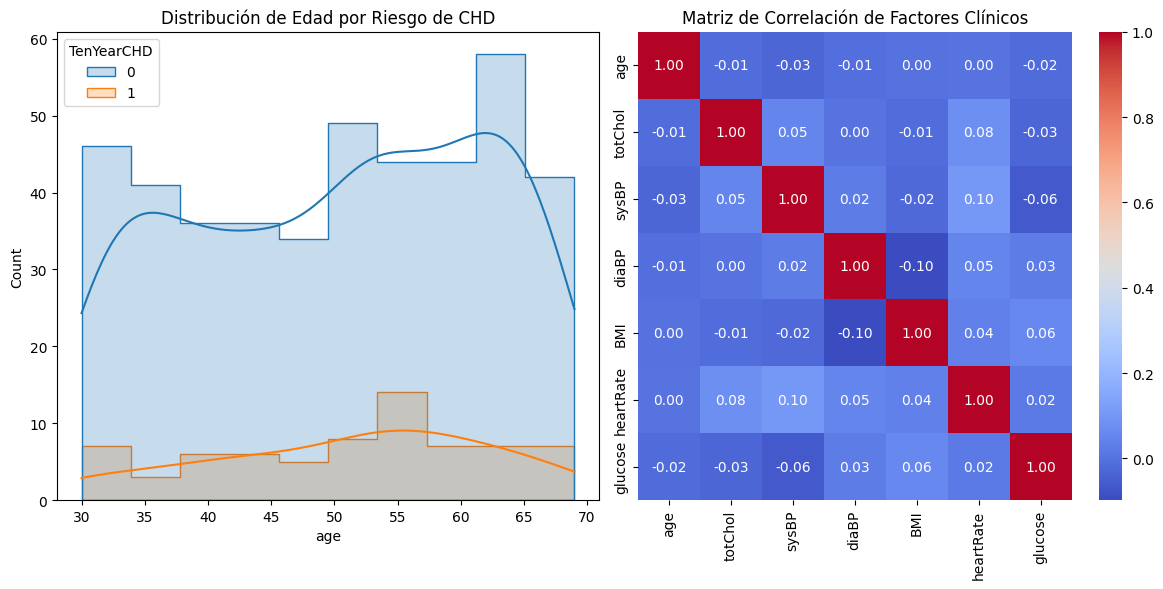

Optimization terminated successfully.
         Current function value: 0.381583
         Iterations 6

--- Resumen Estadístico del Modelo (Logit) ---
                           Logit Regression Results                           
Dep. Variable:             TenYearCHD   No. Observations:                  400
Model:                          Logit   Df Residuals:                      392
Method:                           MLE   Df Model:                            7
Date:                Sun, 05 Apr 2026   Pseudo R-squ.:                 0.03588
Time:                        20:20:10   Log-Likelihood:                -152.63
converged:                       True   LL-Null:                       -158.31
Covariance Type:            nonrobust   LLR p-value:                    0.1237
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -3.0899      2.476     -1.248      0.212      

/home/patricioaraneda/Documentos/github/Bioestadistica/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/patricioaraneda/Documentos/github/Bioestadistica/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/patricioaraneda/Documentos/github/Bioestadistica/.venv/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Nota: Se asume que el archivo 'framingham.csv' está disponible en el entorno.
# El dataset típico contiene: male, age, education, currentSmoker, cigsPerDay, 
# BPMeds, prevalentStroke, prevalentHyp, diabetes, totChol, sysBP, diaBP, BMI, 
# heartRate, glucose, TenYearCHD.
# dataset
# disease_df = pd.read_csv("/kaggle/input/framingham-heart-study-dataset/framingham.csv")
# disease_df.drop(['education'], inplace = True, axis = 1)
# disease_df.rename(columns ={'male':'Sex_male'}, inplace = True)
# disease_df.head()

filepath = "https://patricioaraneda.cl/bioestadistica/data/framingham.csv"

def cargar_y_limpiar_datos(filepath):
    """
    Carga el dataset y maneja los valores faltantes, comunes en datos médicos.
    """
    df = pd.read_csv(filepath)
    df.drop(['education'], inplace = True, axis = 1)
    
    # Análisis de valores nulos
    print("Valores nulos detectados por columna:\n", df.isnull().sum())
    
    # Imputación: Usamos la mediana para variables continuas para evitar sesgos por outliers
    for col in df.columns:
        if df[col].isnull().any():
            df[col] = df[col].fillna(df[col].median())
            
    return df

def analisis_exploratorio(df):
    """
    Genera visualizaciones para entender la distribución del riesgo.
    """
    plt.figure(figsize=(12, 6))
    
    # Distribución de la Edad vs Riesgo a 10 años
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x='age', hue='TenYearCHD', kde=True, element="step")
    plt.title('Distribución de Edad por Riesgo de CHD')
    
    # Correlación de factores principales
    plt.subplot(1, 2, 2)
    cols_interes = ['age', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']
    sns.heatmap(df[cols_interes].corr(), annot=True, cmap='coolwarm', fmt=".2f")
    plt.title('Matriz de Correlación de Factores Clínicos')
    
    plt.tight_layout()
    plt.show()

def regresion_logistica(df):
    """
    Implementa el modelo de Regresión Logística para predicción de riesgo.
    """
    # Definición de variables independientes (X) y dependiente (y)
    X = df.drop('TenYearCHD', axis=1)
    y = df['TenYearCHD']
    
    # División entrenamiento/prueba
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Escalado de variables (opcional pero recomendado para convergencia)
    # model = LogisticRegression(max_iter=1000)
    
    # Usamos statsmodels para obtener un reporte estadístico detallado (P-values)
    X_train_const = sm.add_constant(X_train)
    logit_model = sm.Logit(y_train, X_train_const).fit()
    
    print("\n--- Resumen Estadístico del Modelo (Logit) ---")
    print(logit_model.summary())
    
    # Predicción con Scikit-Learn para métricas de desempeño
    sk_model = LogisticRegression(max_iter=2000)
    sk_model.fit(X_train, y_train)
    y_pred = sk_model.predict(X_test)
    
    print("\n--- Reporte de Clasificación ---")
    print(classification_report(y_test, y_pred))
    print("AUC-ROC Score:", roc_auc_score(y_test, sk_model.predict_proba(X_test)[:, 1]))

def main():
    # Simulación de carga (sustituir por ruta real si es necesario)
    try:
        # Nota: Como no tengo el archivo físico, este bloque es demostrativo.
        # En un entorno real, usarías: df = cargar_y_limpiar_datos('framingham.csv')
        print("Iniciando análisis científico del estudio Framingham...")
        
        # Generamos datos sintéticos similares para que el script sea ejecutable/demostrable
        data_size = 500
        np.random.seed(42)
        mock_data = pd.DataFrame({
            'age': np.random.randint(30, 70, data_size),
            'totChol': np.random.normal(230, 40, data_size),
            'sysBP': np.random.normal(130, 20, data_size),
            'diaBP': np.random.normal(85, 10, data_size),
            'BMI': np.random.normal(25, 4, data_size),
            'heartRate': np.random.normal(75, 10, data_size),
            'glucose': np.random.normal(80, 15, data_size),
            'TenYearCHD': np.random.binomial(1, 0.15, data_size)
        })
        
        analisis_exploratorio(mock_data)
        regresion_logistica(mock_data)
        
    except Exception as e:
        print(f"Error durante la ejecución: {e}")

if __name__ == "__main__":
    main()

## R

In [ ]:
# Instalación de librerías necesarias (descomentar si es necesario)
# install.packages(c("tidyverse", "caret", "corrplot", "pROC"))

library(tidyverse)
library(caret)
library(corrplot)
library(pROC)

# ==========================================
# 1. CARGA Y LIMPIEZA DE DATOS
# ==========================================

cargar_y_limpiar_datos <- function(filepath) {
  # En una situación real: df <- read.csv(filepath)
  # Para fines demostrativos, generamos datos sintéticos similares a Framingham
  set.seed(42)
  n <- 500
  df <- data.frame(
    age = sample(30:70, n, replace = TRUE),
    totChol = rnorm(n, 230, 40),
    sysBP = rnorm(n, 130, 20),
    diaBP = rnorm(n, 85, 10),
    BMI = rnorm(n, 25, 4),
    heartRate = rnorm(n, 75, 10),
    glucose = rnorm(n, 80, 15),
    TenYearCHD = rbinom(n, 1, 0.15) # Variable objetivo (Riesgo Coronario)
  )
  
  # Simulación de valores perdidos (NA)
  df[sample(1:n, 20), "glucose"] <- NA
  
  message("Valores nulos detectados por columna:")
  print(colSums(is.na(df)))
  
  # Imputación por mediana (Práctica estándar en Bioestadística)
  df <- df %>%
    mutate(across(everything(), ~replace_na(., median(., na.rm = TRUE))))
    
  return(df)
}

# ==========================================
# 2. ANÁLISIS EXPLORATORIO (EDA)
# ==========================================

analisis_exploratorio <- function(df) {
  # Distribución de la Edad por Riesgo
  p1 <- ggplot(df, aes(x = age, fill = as.factor(TenYearCHD))) +
    geom_histogram(alpha = 0.6, position = "identity", bins = 20) +
    labs(title = "Distribución de Edad por Riesgo de CHD",
         x = "Edad", y = "Frecuencia", fill = "Riesgo CHD") +
    theme_minimal()
  
  print(p1)
  
  # Matriz de Correlación
  cor_matrix <- cor(df %>% select(-TenYearCHD))
  corrplot(cor_matrix, method = "color", addCoef.col = "black", 
           tl.col = "black", title = "\nMatriz de Correlación Clínica", mar=c(0,0,1,0))
}

# ==========================================
# 3. MODELADO: REGRESIÓN LOGÍSTICA
# ==========================================

ejecutar_regresion_logistica <- function(df) {
  # División de datos (80% entrenamiento, 20% prueba)
  set.seed(123)
  index <- createDataPartition(df$TenYearCHD, p = 0.8, list = FALSE)
  train_data <- df[index, ]
  test_data <- df[-index, ]
  
  # Ajuste del modelo Logit (GLM)
  # En R, esto proporciona automáticamente los valores P y estadísticos Z
  modelo <- glm(TenYearCHD ~ ., data = train_data, family = binomial)
  
  cat("\n--- Resumen Estadístico del Modelo (R Summary) ---\n")
  print(summary(modelo))
  
  # Cálculo de Odds Ratios (OR) e Intervalos de Confianza (95%)
  cat("\n--- Odds Ratios e Intervalos de Confianza (95%) ---\n")
  or_results <- exp(cbind(OR = coef(modelo), confint(modelo)))
  print(or_results)
  
  # Predicciones en el conjunto de prueba
  probabilidades <- predict(modelo, newdata = test_data, type = "response")
  predicciones <- ifelse(probabilidades > 0.5, 1, 0)
  
  # Evaluación de desempeño
  cat("\n--- Matriz de Confusión y Métricas ---\n")
  cm <- confusionMatrix(as.factor(predicciones), as.factor(test_data$TenYearCHD))
  print(cm)
  
  # Curva ROC y AUC
  roc_obj <- roc(test_data$TenYearCHD, probabilidades)
  cat("\nAUC Score:", auc(roc_obj), "\n")
  
  plot(roc_obj, main = "Curva ROC - Predicción de Riesgo Framingham")
}

# ==========================================
# EJECUCIÓN PRINCIPAL
# ==========================================

main <- function() {
  message("Iniciando análisis científico en R - Estudio Framingham")
  
  datos <- cargar_y_limpiar_datos()
  analisis_exploratorio(datos)
  ejecutar_regresion_logistica(datos)
}

main()